In [13]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import astropy.units as u

from analysis_electrons.general_spectrum_analysis import volume_approximation
from config.plotting import set_plotting_defaults, Tab10, save_figure
from config.units import Gauss, flux_unit
from analysis_protons.spectrum_complex_fit_protons import ProtonElectronSpectrumFit
from config.settings import MCMC_PROTONS, SPECTRUM_DIR, SYNCH_INTERP_DIR

set_plotting_defaults()

In [14]:
data = pickle.load(open(os.path.join(SPECTRUM_DIR, "UHE_spectrum_corrected.pck"), "rb"))
names, e, f_cor, f_l_cor, f_p_cor, e_l, e_p = data

In [15]:
bvalue = 40.0
bfield = bvalue * 1e-6 * Gauss

nsteps, nwalkers = 400, 8
data = pickle.load(open(os.path.join(MCMC_PROTONS, f"protons_{nsteps}n_{nwalkers}w_{bvalue}uG.pck"), "rb"))
result = data[0]
psf: ProtonElectronSpectrumFit = data[1]

In [16]:
result_mod = result[(result[:, 1] < 2.5) * (result[:, 2] < 5)]

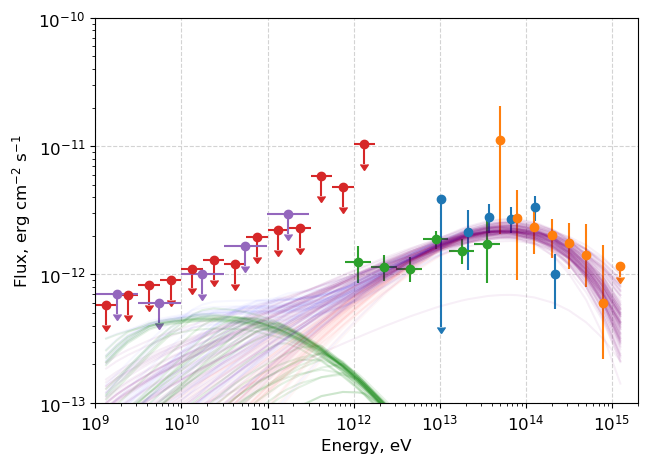

In [17]:
for i, name in enumerate(names):
    plt.errorbar(e[i], f_cor[i], xerr=[e_l[i], e_p[i]], yerr=[f_l_cor[i], f_p_cor[i]],
                 fmt='o', linestyle='None', uplims=f_p_cor[i] <= 0,
                 color=Tab10[i], label=f' ')

for res in result_mod[::]:
    plt.plot(psf.photon_energy, psf.model(res), alpha=.03, color='blue')
    plt.plot(psf.photon_energy, psf.proton_photons(res), alpha=.03, color='red')
    plt.plot(psf.photon_energy, psf.electron_photons(res), alpha=.1, color='green')

plt.xscale('log')
plt.xlim(1e9, 2e15)
plt.xlabel("Energy, eV")

plt.yscale('log')
plt.ylim(1e-13, 1e-10)
plt.ylabel(r"Flux, $\mathrm{erg~cm^{-2}~s^{-1}}$")

# save_figure("spectrum_with_a_proton_fit_mcmc")
plt.show()

<Figure size 1000x800 with 0 Axes>

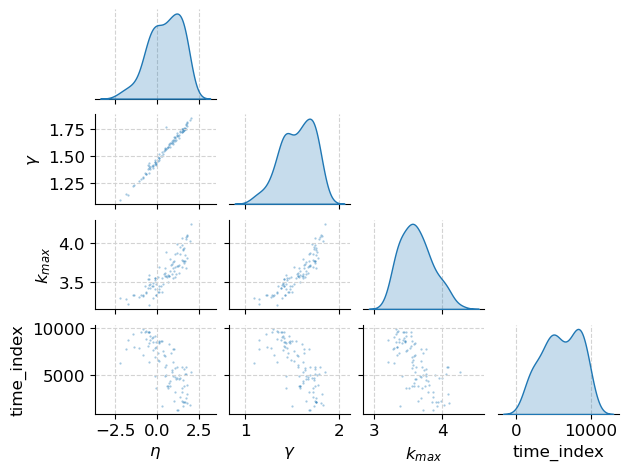

In [18]:
columns = [r"$\eta$", r"$\gamma$", r"$k_{max}$", r"time_index"]
fs = pd.DataFrame(result_mod, columns=columns)
# print(np.mean(result_mod, axis=0))

plt.figure(figsize=(10, 8))
sns.pairplot(fs, diag_kind="kde",
             plot_kws=dict(marker=".", linewidth=0, alpha=.4, s=10),
             corner=True, height=1.2, aspect=4/3)
# g.map_lower(sns.kdeplot, levels=5, color=".2", alpha=.3)

In [19]:
# SYNCHROTRON RADIATON SETTING
synch_photon_energy = np.logspace(0, 15, 100) * u.eV

e_volume = volume_approximation(psf.electron_energy)

path = os.path.join(SYNCH_INTERP_DIR, f"synch_power_interp_{bfield.value * 1e6:.1f}.pck")
synch_interp_data = pickle.load(open(path, "rb"))

synch_interp = synch_interp_data[2]

lg_ee = np.log10(psf.electron_energy.value)
lg_pe = np.log10(synch_photon_energy.value)

ee_pe, pe_ee = np.meshgrid(lg_ee, lg_pe, indexing='ij')
synch_table = 10**synch_interp((ee_pe, pe_ee)) * (1/u.s)

In [20]:
result_chosen = result_mod

synch_flux_fast = np.zeros([result_chosen.shape[0], synch_photon_energy.size]) * flux_unit
sec_flux_tot = np.zeros([result_chosen.shape[0], psf.electron_energy.size]) * flux_unit

for i, res_i in enumerate(result_chosen):
    sec_density = psf.secondary_electrons(res_i)
    synch_lum = np.trapezoid(synch_table.T * sec_density, psf.electron_energy, axis=1)
    synch_flux_fast[i] = synch_lum * synch_photon_energy / psf.area

In [21]:
new_photon_energy = np.logspace(7, 18, 200) * u.eV

psf.photon_energy = new_photon_energy
(psf.e_prim, psf.above_cutoff, psf.below_cutoff,
psf.e_sec,
psf.he_cs_matrix, psf.le_cs_matrix) = psf.get_cs_matrices()

psf.photon_energy = new_photon_energy

(psf.e_prim, psf.above_cutoff, psf.below_cutoff,
psf.e_sec_phot,
psf.he_cs_matrix, psf.le_cs_matrix) = psf.get_cs_matrices()

_, psf.radiation_matrix = psf.set_radiation_matrix(photon_energy=new_photon_energy)

In [22]:
ans = []
ans2 = []
for i, res_i in enumerate(result_chosen):
    ans.append(psf.proton_photons(res_i))
    ans2.append(psf.electron_photons(res_i))

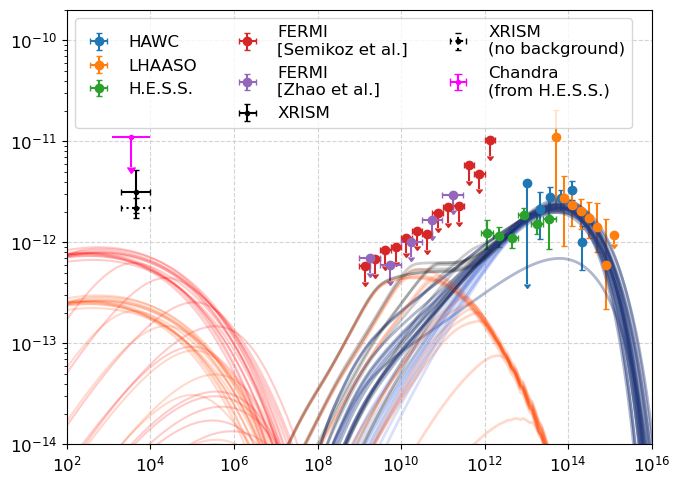

In [33]:
from spectrum.measurements_xray import constraint_XRISM, constraint_Chandra, weak_constraint_XRISM

# UHE spectrum
data = pickle.load(open(os.path.join(SPECTRUM_DIR, "UHE_spectrum_corrected.pck"), "rb"))
names, e, f_cor, f_l_cor, f_p_cor, e_l, e_p = data
names_short = ["HAWC", "LHAASO", "H.E.S.S.", "FERMI\n[Semikoz et al.]", "FERMI\n[Zhao et al.]"]

set_plotting_defaults()
plt.figure(figsize=(7, 5))
for i, name in enumerate(names):
    plt.errorbar(e[i], f_cor[i], xerr=[e_l[i], e_p[i]], yerr=[f_l_cor[i], f_p_cor[i]],
                 fmt='o', linestyle='None', uplims=f_p_cor[i] <= 0, capsize=2,
                 color=Tab10[i], label=names_short[i])
# X-Ray corrected
e, f, f_l, f_p, e_l, e_p = constraint_XRISM()
plt.errorbar(e, f, xerr=[e_l, e_p], yerr=[f_l, f_p], color='black', capsize=2,
             marker='o', markersize=3, label='XRISM', linestyle='None')
e, f, f_l, f_p, e_l, e_p = weak_constraint_XRISM()
eb = plt.errorbar(e, f, xerr=[e_l, e_p], yerr=[f_l, f_p], color='black', capsize=2,
                  marker='o', markersize=3, label='XRISM\n(no background)', linestyle='None')
eb[-1][0].set_linestyle(':')
e, f, f_l, f_p, e_l, e_p = constraint_Chandra()
plt.errorbar(e, f, xerr=[e_l, e_p], yerr=0.5 * f, uplims=True,
             marker='o', markersize=3, label='Chandra\n(from H.E.S.S.)', linestyle='None',
             color='magenta')
plt.errorbar(1, 1, linewidth=0, label=' ', marker=None)

a_g = .2
for i, res_i in enumerate(result_chosen):
    if i % 4 != 0:
        continue
    """if res_i[-1] < 7800:
        continue"""
    plt.plot(psf.photon_energy, ans[i] + ans2[i], alpha=a_g, color='black', linewidth=2)
    plt.plot(psf.photon_energy, ans[i], alpha=a_g, color='royalblue', linewidth=2)
    plt.plot(psf.photon_energy, ans2[i], alpha=a_g, color='orangered', linewidth=2)
    plt.plot(synch_photon_energy, synch_flux_fast[i] / 3, alpha=a_g, color='orangered')
    plt.loglog(synch_photon_energy, synch_flux_fast[i], alpha=a_g, color='red')

plt.ylim(1e-14, 2e-10)
plt.xlim(1e2, 1e16)

plt.legend(loc=2, ncol=3)

plt.tight_layout()
# save_figure("proton_UHE_fit_40uG")
plt.show()

In [24]:
print((psf.spectrum.tot_e(eta=res[0], p=res[1], k1=-10.0, k2=res[2])).to(u.erg))
print(psf.density)

3.0013625353046117e+50 erg
1.0 1 / cm3
